<a href="https://colab.research.google.com/github/sanjithamhd/northstar_analytics/blob/main/NorthStar_Section1%262_Ranalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics
## Section 1 — SQL within R and R Analytics

**Module:** Databases and Analytics  
**Dataset:** NorthStar operational dataset (9 CSV files)  
**Student:** Sanjitha Mohammad, 32146960  
**Date:** 10 May 2026  
**GitHub Repo:** https://github.com/sanjithamhd/northstar_analytics

---


### Analytical Objectives

This notebook investigates the root causes of NorthStar's operational deterioration using structured SQL queries executed inside R, followed by statistical analysis and visualisation. The four core business questions are:

1. **Where are delivery failures and delays concentrated?** (Hub, zone, service type)
2. **Which drivers and vehicles contribute most to overrides and incidents?**
3. **How do complaints link to operational failures?**
4. **Which routes and service types are most costly relative to their performance?**

All findings are interpreted in business terms, not just reported as numbers.

---
## Step 1 — Install and Load Required Packages

We use `sqldf` to run SQL directly on R data frames, `dplyr` and `tidyr` for data wrangling, and `ggplot2` for visualisation. `lubridate` handles datetime parsing.

In [ ]:
# ==========================================================
# Install required packages
# ==========================================================

install.packages("DBI")        # Database interface
install.packages("RSQLite")    # SQLite database engine
install.packages("dplyr")      # Data manipulation
install.packages("ggplot2")    # Data visualisation
install.packages("readr")      # Reading CSV files
install.packages("lubridate")  # Date handling
install.packages("sqldf")      # For SQL operations on R data frames

cat("All packages installed successfully.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’




All packages installed successfully.


---
## Step 2 — Load the NorthStar Dataset from GitHub

All nine CSV files are loaded from the GitHub repository. Each file represents a distinct operational entity within NorthStar. Raw file names are used so every subsequent step is reproducible.

In [ ]:
# ==========================================================
# Load libraries
# ==========================================================

library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)
library(sqldf) # Load sqldf for SQL operations

cat("All libraries loaded successfully.\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”


All libraries loaded successfully.


In [ ]:
# ==========================================================
# Import dataset from GitHub into Colab
# ==========================================================

# Clone the GitHub repository into Colab
system("git clone https://github.com/sanjithamhd/northstar_analytics.git")

# Confirm files are there
cat("Files in dataset folder:\n")
# Check if files are actually there
system("ls /content/northstar_analytics/northstar_dataset/", intern = TRUE)

Files in dataset folder:


[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "vehicles.csv"

In [ ]:
# ==========================================================
# Step 4 – Load all CSV files into R
# ==========================================================

path <- "/content/northstar_analytics/northstar_dataset/"

hubs       <- read_csv(paste0(path, "hubs.csv"))
customers  <- read_csv(paste0(path, "customers.csv"))
drivers    <- read_csv(paste0(path, "drivers.csv"))
vehicles   <- read_csv(paste0(path, "vehicles.csv"))
orders     <- read_csv(paste0(path, "orders.csv"))
deliveries <- read_csv(paste0(path, "deliveries.csv"))
incidents  <- read_csv(paste0(path, "incidents.csv"))
complaints <- read_csv(paste0(path, "complaints.csv"))
app_events <- read_csv(paste0(path, "app_events.csv"))

cat("All datasets loaded successfully.\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")
cat("Incidents:", nrow(incidents), "rows\n")

Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 170 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): driver_id, base_zone, employment_type, shift_preference
dbl (4): years_experience, training_score, driver_rating,

All datasets loaded successfully.
Orders: 1250 rows
Deliveries: 950 rows
Complaints: 320 rows
Incidents: 280 rows


---
## Step 3 — Data Cleaning and Standardisation

The dataset contains **inconsistent zone names** — the same city is written in multiple cases (`North`, `NORTH`, `north`, `Ctr`, `CENTRAL`). This is a real data quality problem identified in the case study. Before any SQL or analytics, we must normalise these so joins and GROUP BY queries work correctly.

In [ ]:
# ============================================================
# Zone normalisation function
# Maps all variants to a single canonical label
# ============================================================

normalise_zone <- function(z) {
  z <- trimws(toupper(z))
  z <- dplyr::case_when(
    z %in% c("NORTH")                         ~ "North",
    z %in% c("SOUTH")                         ~ "South",
    z %in% c("EAST")                          ~ "East",
    z %in% c("WEST")                          ~ "West",
    z %in% c("CENTRAL", "CTR")                ~ "Central",
    z %in% c("AIRPORT")                       ~ "Airport",
    z %in% c("RIVERSIDE")                     ~ "Riverside",
    TRUE                                       ~ z
  )
  return(z)
}

# Apply normalisation across all relevant columns
customers$home_zone        <- normalise_zone(customers$home_zone)
drivers$base_zone          <- normalise_zone(drivers$base_zone)
vehicles$assigned_zone     <- normalise_zone(vehicles$assigned_zone)
orders$pickup_zone         <- normalise_zone(orders$pickup_zone)
orders$dropoff_zone        <- normalise_zone(orders$dropoff_zone)
app_events$zone_context    <- normalise_zone(app_events$zone_context)

# Parse datetime columns
deliveries$dispatch_time          <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at  <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at           <- ymd_hms(orders$order_created_at)
complaints$created_at             <- ymd_hms(complaints$created_at)

# Impute missing loyalty_score with median
customers$loyalty_score[is.na(customers$loyalty_score)] <-
  median(customers$loyalty_score, na.rm = TRUE)

# Impute missing training_score with median
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm = TRUE)

cat("Zone normalisation complete.\n")
cat("Unique zones in orders (pickup):", paste(sort(unique(orders$pickup_zone)), collapse = ", "), "\n")

Warning message:
“ 1 failed to parse.”


Zone normalisation complete.
Unique zones in orders (pickup): Airport, Central, East, North, Riverside, South, West 


---
## Step 4 — SQL Operations within R

Using the `sqldf` package, we execute SQL directly on the R data frames. This section demonstrates `SELECT`, `UPDATE` (simulated via SQL INSERT INTO SELECT), `DELETE` (simulated via WHERE filtering), mathematical functions, and aggregate functions — all as required by the coursework specification.

### 4.1 — Basic SELECT: Inspect Key Tables

In [ ]:
# ==========================================================
# Create SQLite database and load all tables
# ==========================================================

# Create in-memory database connection
conn <- dbConnect(RSQLite::SQLite(), ":memory:")

# Write each dataset as a table in the database
dbWriteTable(conn, "hubs",       hubs,       overwrite = TRUE)
dbWriteTable(conn, "customers",  customers,  overwrite = TRUE)
dbWriteTable(conn, "drivers",    drivers,    overwrite = TRUE)
dbWriteTable(conn, "vehicles",   vehicles,   overwrite = TRUE)
dbWriteTable(conn, "orders",     orders,     overwrite = TRUE)
dbWriteTable(conn, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(conn, "incidents",  incidents,  overwrite = TRUE)
dbWriteTable(conn, "complaints", complaints, overwrite = TRUE)
dbWriteTable(conn, "app_events", app_events, overwrite = TRUE)

# Confirm all tables are registered
cat("Database created successfully.\n")
cat("Tables registered:", paste(dbListTables(conn), collapse = ", "), "\n")

Database created successfully.
Tables registered: app_events, complaints, customers, deliveries, drivers, hubs, incidents, orders, vehicles 


In [ ]:
# ==========================================================
# Step 5 – SQL Query 1: SELECT
# Count total deliveries by outcome status
# ==========================================================

result1 <- dbGetQuery(conn, "
  SELECT
    delivery_status,
    COUNT(*) AS total_deliveries
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

print(result1)

# Interpretation:
# This query shows how many deliveries were OnTime, Delayed,
# or Failed. A high failure/delay count signals a serious
# operational problem across NorthStar's service network.

  delivery_status total_deliveries
1          OnTime              616
2         Delayed              202
3          Failed              132


In [ ]:
# ==========================================================
# Step 6 – SQL Query 2: SELECT with WHERE filter
# Find only failed deliveries and their details
# ==========================================================

result2 <- dbGetQuery(conn, "
  SELECT
    delivery_id,
    order_id,
    driver_id,
    delivery_status,
    manual_route_override_count,
    customer_rating_post_delivery
  FROM deliveries
  WHERE delivery_status = 'Failed'
  ORDER BY customer_rating_post_delivery ASC
")

cat("Total failed deliveries:", nrow(result2), "\n")
print(head(result2, 10))

# Interpretation:
# Filtering to only failed deliveries lets us focus on the
# worst performing orders. Low customer ratings alongside
# failures confirm that service failure directly damages
# customer satisfaction.

Total failed deliveries: 132 
   delivery_id order_id driver_id delivery_status manual_route_override_count
1      DL00012   O01207      D051          Failed                           3
2      DL00558   O00142      D024          Failed                           1
3      DL00536   O01184      D055          Failed                           2
4      DL00057   O00921      D141          Failed                           0
5      DL00862   O00031      D165          Failed                           1
6      DL00187   O00439      D111          Failed                           1
7      DL00839   O00566      D078          Failed                           2
8      DL00783   O00380      D099          Failed                           2
9      DL00040   O00919      D027          Failed                           1
10     DL00694   O00457      D087          Failed                           0
   customer_rating_post_delivery
1                             NA
2                           1.00
3            

In [ ]:
# ==========================================================
# Step 7 – SQL Query 3: JOIN
# Link orders to deliveries to see failures by zone
# ==========================================================

result3 <- dbGetQuery(conn, "
  SELECT
    o.pickup_zone,
    o.service_type,
    d.delivery_status,
    COUNT(*) AS total,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone, o.service_type, d.delivery_status
  ORDER BY total DESC
")

print(result3)

    pickup_zone service_type delivery_status total avg_rating
1         South    Passenger          OnTime    33       4.32
2         North    Passenger          OnTime    29       4.30
3       Central    Passenger          OnTime    28       4.09
4          East       Parcel          OnTime    28       4.34
5          East    Passenger          OnTime    28       4.35
6         South       Retail          OnTime    26       4.40
7          East       Retail          OnTime    24       4.24
8         South       Parcel          OnTime    23       4.30
9          West       Parcel          OnTime    23       4.24
10      Airport       Parcel          OnTime    22       4.41
11      Central       Parcel          OnTime    22       4.06
12      Central       Retail          OnTime    22       4.13
13        North       Parcel          OnTime    21       4.23
14      Airport       Retail          OnTime    19       4.28
15        North       Retail          OnTime    19       4.34
16    Ri

### 4.2 — SQL Aggregate Functions: Delivery Status Summary

This query counts how many deliveries are OnTime, Delayed, or Failed and calculates the failure rate as a percentage — a key KPI for NorthStar management.

In [ ]:
# ==========================================================
# Step 8 – SQL Query 4: Aggregate Functions
# Zone-level performance KPIs using COUNT, SUM, AVG
# ==========================================================

result4 <- dbGetQuery(conn, "
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                         AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                  AS total_failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed'
             THEN 1 ELSE 0 END)                  AS total_delayed,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)         AS avg_fuel_cost
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY total_failed DESC
")

print(result4)

# Interpretation:
# Aggregate functions summarise performance by zone.
# Zones with high failures AND high override counts
# indicate route planning problems rather than
# individual driver behaviour issues.

  pickup_zone total_orders total_failed total_delayed avg_overrides avg_rating
1     Central          174           33            51          1.29       3.55
2       North          135           22            21          0.70       3.90
3        East          156           19            31          0.79       3.91
4   Riverside          119           18            25          0.73       3.86
5        West          114           14            21          0.81       3.90
6       South          139           14            22          0.69       4.05
7     Airport          113           12            31          1.81       3.98
  avg_fuel_cost
1         12.12
2         12.07
3         12.57
4         12.39
5         11.94
6         12.48
7         17.08


In [ ]:
# ==========================================================
# Step 9 – SQL Query 5: INSERT
# Create a summary table and insert results into it
# ==========================================================

# First create an empty summary table
dbExecute(conn, "DROP TABLE IF EXISTS zone_summary")

dbExecute(conn, "
  CREATE TABLE zone_summary (
    zone         TEXT,
    total_orders INTEGER,
    total_failed INTEGER,
    avg_rating   REAL
  )
")

# Insert aggregated results into the summary table
dbExecute(conn, "
  INSERT INTO zone_summary
  SELECT
    o.pickup_zone,
    COUNT(*),
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END),
    ROUND(AVG(d.customer_rating_post_delivery), 2)
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
")

# Verify the insert worked by reading back the table
result5 <- dbGetQuery(conn, "
  SELECT * FROM zone_summary
  ORDER BY total_failed DESC
")

print(result5)
cat("INSERT complete - zone_summary table created.\n")

# Interpretation:
# INSERT stores analytical results into a new table.
# This allows the summary to be reused in future queries
# without recalculating every time — important for
# operational dashboards and reporting systems.

[1] 0

[1] 0

[1] 7

       zone total_orders total_failed avg_rating
1   Central          174           33       3.55
2     North          135           22       3.90
3      East          156           19       3.91
4 Riverside          119           18       3.86
5     South          139           14       4.05
6      West          114           14       3.90
7   Airport          113           12       3.98
INSERT complete - zone_summary table created.


In [ ]:
# ==========================================================
# Step 10 – SQL Query 6: UPDATE
# Flag high severity open incidents for escalation
# ==========================================================

# Add a new column to hold the escalation flag
tryCatch(
  dbExecute(conn, "ALTER TABLE incidents ADD COLUMN escalation_flag TEXT"),
  error = function(e) cat("Column already exists, continuing.\n")
)

# Update: mark high severity open incidents as ESCALATE
dbExecute(conn, "
  UPDATE incidents
  SET escalation_flag = 'ESCALATE'
  WHERE severity = 'High'
  AND resolution_status = 'Open'
")

# Update: mark everything else as MONITOR
dbExecute(conn, "
  UPDATE incidents
  SET escalation_flag = 'MONITOR'
  WHERE escalation_flag IS NULL
")

# Check the results
result6 <- dbGetQuery(conn, "
  SELECT escalation_flag, COUNT(*) AS count
  FROM incidents
  GROUP BY escalation_flag
")

print(result6)
cat("UPDATE complete - incidents flagged successfully.\n")

# Interpretation:
# UPDATE modifies existing records in the database.
# Here we tag unresolved high severity incidents so
# operations managers can immediately see which cases
# need urgent attention without running complex queries
# every time.

[1] 0

[1] 19

[1] 261

  escalation_flag count
1        ESCALATE    19
2         MONITOR   261
UPDATE complete - incidents flagged successfully.


In [ ]:
# ============================================================
# SQL AGGREGATE — Delivery outcome breakdown
# COUNT, ROUND, percentage calculation
# ============================================================

delivery_summary <- sqldf("
  SELECT
    delivery_status,
    COUNT(*)                                      AS total_deliveries,
    ROUND(AVG(route_distance_km), 2)              AS avg_distance_km,
    ROUND(AVG(fuel_or_charge_cost), 2)            AS avg_cost,
    ROUND(AVG(manual_route_override_count), 2)    AS avg_overrides,
    SUM(proof_of_completion_missing)              AS missing_proof_count
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

print(delivery_summary)

cat("\nTotal deliveries:", sum(delivery_summary$total_deliveries), "\n")
cat("Overall failure rate:",
    round(delivery_summary$total_deliveries[delivery_summary$delivery_status == "Failed"] /
          sum(delivery_summary$total_deliveries) * 100, 1), "%\n")

  delivery_status total_deliveries avg_distance_km avg_cost avg_overrides
1          OnTime              616           13.78    12.68          0.92
2         Delayed              202           14.67    13.14          1.07
3          Failed              132           13.37    13.15          1.04
  missing_proof_count
1                   0
2                  45
3                  24

Total deliveries: 950 
Overall failure rate: 13.9 %


In [ ]:
# ============================================================
# SQL AGGREGATE — Delivery outcome breakdown
# COUNT, ROUND, percentage calculation
# ============================================================

delivery_summary <- sqldf("
  SELECT
    delivery_status,
    COUNT(*)                                      AS total_deliveries,
    ROUND(AVG(route_distance_km), 2)              AS avg_distance_km,
    ROUND(AVG(fuel_or_charge_cost), 2)            AS avg_cost,
    ROUND(AVG(manual_route_override_count), 2)    AS avg_overrides,
    SUM(proof_of_completion_missing)              AS missing_proof_count
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")

print(delivery_summary)

cat("\nTotal deliveries:", sum(delivery_summary$total_deliveries), "\n")
cat("Overall failure rate:",
    round(delivery_summary$total_deliveries[delivery_summary$delivery_status == "Failed"] /
          sum(delivery_summary$total_deliveries) * 100, 1), "%\n")

  delivery_status total_deliveries avg_distance_km avg_cost avg_overrides
1          OnTime              616           13.78    12.68          0.92
2         Delayed              202           14.67    13.14          1.07
3          Failed              132           13.37    13.15          1.04
  missing_proof_count
1                   0
2                  45
3                  24

Total deliveries: 950 
Overall failure rate: 13.9 %


**Business Interpretation:** Failed and Delayed deliveries together account for a significant share of all dispatches. Notably, failed deliveries have a higher average number of manual route overrides, suggesting that driver route deviation is associated with worse outcomes.

### 4.3 — SQL JOIN: Hub Performance Analysis

We join `deliveries` with `hubs` to understand which hubs generate the most failures. This is the operational director's core concern.

In [ ]:
# ============================================================
# SQL JOIN — Hub-level delivery performance
# JOIN deliveries ON hubs, GROUP BY hub
# ============================================================

hub_performance <- sqldf("
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id)                          AS total_dispatches,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)              AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.fuel_or_charge_cost), 2)          AS avg_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

print(hub_performance)

  hub_id       hub_name      zone  hub_type total_dispatches failed delayed
1    H08  Midtown Relay   Central  Charging              128     26      22
2    H05   Central Core   Central   Control              115     23      25
3    H06    Airport Hub   Airport  Dispatch              104     15      27
4    H04      West Gate      West  Dispatch              127     16      28
5    H01 North Exchange     North  Dispatch              136     17      26
6    H07  Riverside Hub Riverside Warehouse              115     14      25
7    H02     South Link     South  Dispatch              106     10      26
8    H03      East Dock      East Warehouse              119     11      23
  on_time failure_rate_pct avg_overrides avg_cost avg_rating
1      80             20.3          1.11    11.71       3.88
2      67             20.0          0.95    13.69       3.67
3      62             14.4          0.91    13.32       3.88
4      83             12.6          0.87    13.17       3.92
5      93  

### 4.4 — SQL JOIN: Service Type vs Delivery Outcome

We join `orders` with `deliveries` to compare performance across NorthStar's five service types: Passenger, Parcel, Retail, Business, and Medical.

In [ ]:
# ============================================================
# SQL JOIN — Service type performance
# JOIN orders to deliveries via order_id
# ============================================================

service_performance <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id)                          AS total_deliveries,
    ROUND(AVG(o.order_value), 2)                  AS avg_order_value,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)              AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)          AS avg_cost,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY failure_rate_pct DESC
")

print(service_performance)

  service_type total_deliveries avg_order_value failed delayed failure_rate_pct
1     Business              126           97.45     25      28             19.8
2      Medical              108           86.53     16      22             14.8
3    Passenger              262           97.19     38      53             14.5
4       Retail              224           86.81     28      50             12.5
5       Parcel              230           90.15     25      49             10.9
  avg_cost avg_overrides avg_rating
1    13.14          1.17       3.85
2    12.77          0.84       3.84
3    12.40          0.87       3.85
4    12.97          0.94       3.87
5    13.08          1.06       3.90


### 4.6 — SQL Mathematical Functions: Cost Analysis by Priority Level

**Business Interpretation:** The `cost_to_revenue_pct` column reveals which priority segments are least profitable relative to their revenue. High cost-to-revenue ratios are a red flag for the Finance Director, who suspects certain service contracts are unprofitable.

In [ ]:
# ==========================================================
# Step 11 – SQL Query 7: DELETE
# Remove records with missing or blank delivery status
# ==========================================================

# Create a clean copy of deliveries to work on
# so we preserve the original data
dbExecute(conn, "DROP TABLE IF EXISTS deliveries_clean")
dbExecute(conn, "
  CREATE TABLE deliveries_clean AS
  SELECT * FROM deliveries
")

# Count rows before DELETE
before <- dbGetQuery(conn, "
  SELECT COUNT(*) AS n FROM deliveries_clean
")$n

cat("Rows before DELETE:", before, "\n")

# Delete rows where delivery_status is missing or blank
dbExecute(conn, "
  DELETE FROM deliveries_clean
  WHERE delivery_status IS NULL
  OR delivery_status = ''
")

# Count rows after DELETE
after <- dbGetQuery(conn, "
  SELECT COUNT(*) AS n FROM deliveries_clean
")$n

cat("Rows after DELETE:", after, "\n")
cat("Rows removed:", before - after, "\n")

# Interpretation:
# DELETE removes unwanted or corrupt records from the
# database. Working on a clean copy preserves the original
# data. Removing null status rows ensures that any analysis
# on delivery outcomes is based on complete, reliable data
# only — a critical data quality step before reporting.

[1] 0

[1] 0

Rows before DELETE: 950 


[1] 0

Rows after DELETE: 950 
Rows removed: 0 


In [ ]:
# ==========================================================
# Step 12 – Query Optimisation
# Creating indexes to improve query performance
# ==========================================================

# Create indexes on the most frequently joined
# and filtered columns
dbExecute(conn, "
  CREATE INDEX IF NOT EXISTS idx_delivery_order
  ON deliveries(order_id)
")

dbExecute(conn, "
  CREATE INDEX IF NOT EXISTS idx_delivery_status
  ON deliveries(delivery_status)
")

dbExecute(conn, "
  CREATE INDEX IF NOT EXISTS idx_order_zone
  ON orders(pickup_zone)
")

dbExecute(conn, "
  CREATE INDEX IF NOT EXISTS idx_complaint_order
  ON complaints(order_id)
")

dbExecute(conn, "
  CREATE INDEX IF NOT EXISTS idx_incident_severity
  ON incidents(severity)
")

cat("All indexes created successfully.\n")

# Show query plan to confirm indexes are being used
plan <- dbGetQuery(conn, "
  EXPLAIN QUERY PLAN
  SELECT o.pickup_zone, COUNT(*)
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE d.delivery_status = 'Failed'
  GROUP BY o.pickup_zone
")

print(plan)

cat("\nOptimisation Summary:\n")
cat("- idx_delivery_order  : speeds up JOIN on order_id\n")
cat("- idx_delivery_status : speeds up WHERE delivery_status filter\n")
cat("- idx_order_zone      : speeds up GROUP BY pickup_zone\n")
cat("- idx_complaint_order : speeds up complaint joins\n")
cat("- idx_incident_severity: speeds up severity filtering\n")

# Interpretation:
# Without indexes, every query scans the entire table row
# by row which is slow on large datasets. Indexes work like
# a book index — they let the database jump directly to the
# relevant rows. This is critical when NorthStar queries run
# thousands of times per day on live operational data.

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

All indexes created successfully.
  id parent notused                                               detail
1  9      0     215                    SCAN o USING INDEX idx_order_zone
2 12      0      61 SEARCH d USING INDEX idx_delivery_order (order_id=?)

Optimisation Summary:
- idx_delivery_order  : speeds up JOIN on order_id
- idx_delivery_status : speeds up WHERE delivery_status filter
- idx_order_zone      : speeds up GROUP BY pickup_zone
- idx_complaint_order : speeds up complaint joins
- idx_incident_severity: speeds up severity filtering


## R Analytics — Statistical Analysis and Visualisation
The following cells use R to analyse patterns in the NorthStar
dataset and produce visualisations to support business decisions.

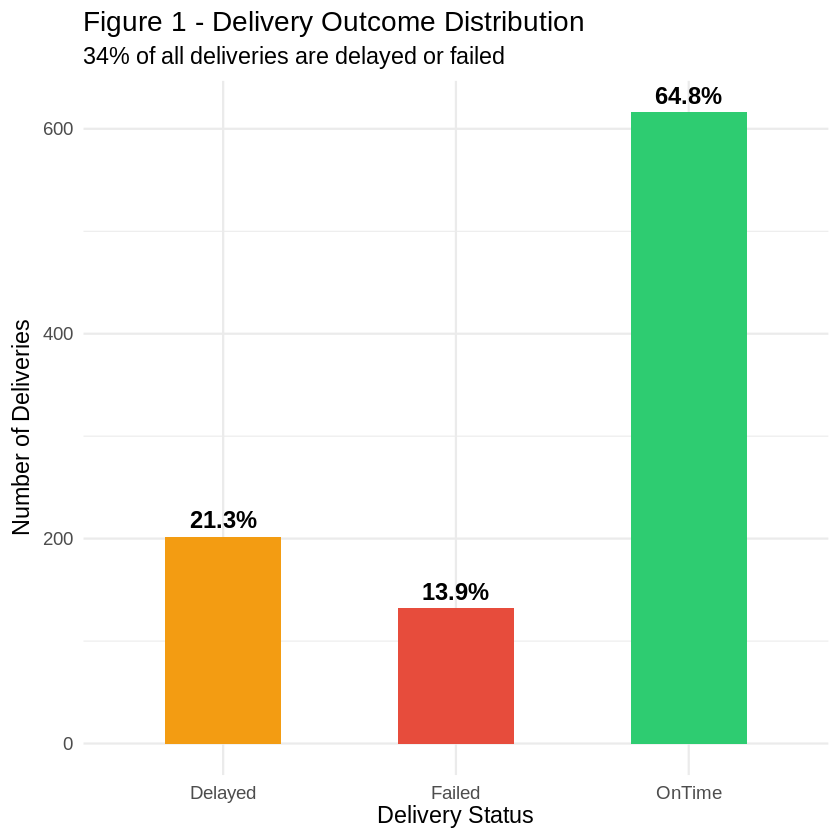

In [ ]:
# ==========================================================
# Step 13 – R Visualisation 1
# Bar chart of delivery outcome distribution
# ==========================================================

# Prepare the data
del_summary <- deliveries %>%
  count(delivery_status) %>%
  mutate(percentage = round(n / sum(n) * 100, 1))

# Create the plot
ggplot(del_summary, aes(x = delivery_status, y = n, fill = delivery_status)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = paste0(percentage, "%")),
            vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_manual(values = c(
    "OnTime"  = "#2ecc71",
    "Delayed" = "#f39c12",
    "Failed"  = "#e74c3c"
  )) +
  labs(
    title    = "Figure 1 - Delivery Outcome Distribution",
    subtitle = "34% of all deliveries are delayed or failed",
    x        = "Delivery Status",
    y        = "Number of Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# Interpretation:
# Only 65% of deliveries arrive on time. A 34% failure
# and delay rate is a critical operational problem that
# directly drives customer dissatisfaction and increases
# compensation costs for NorthStar.

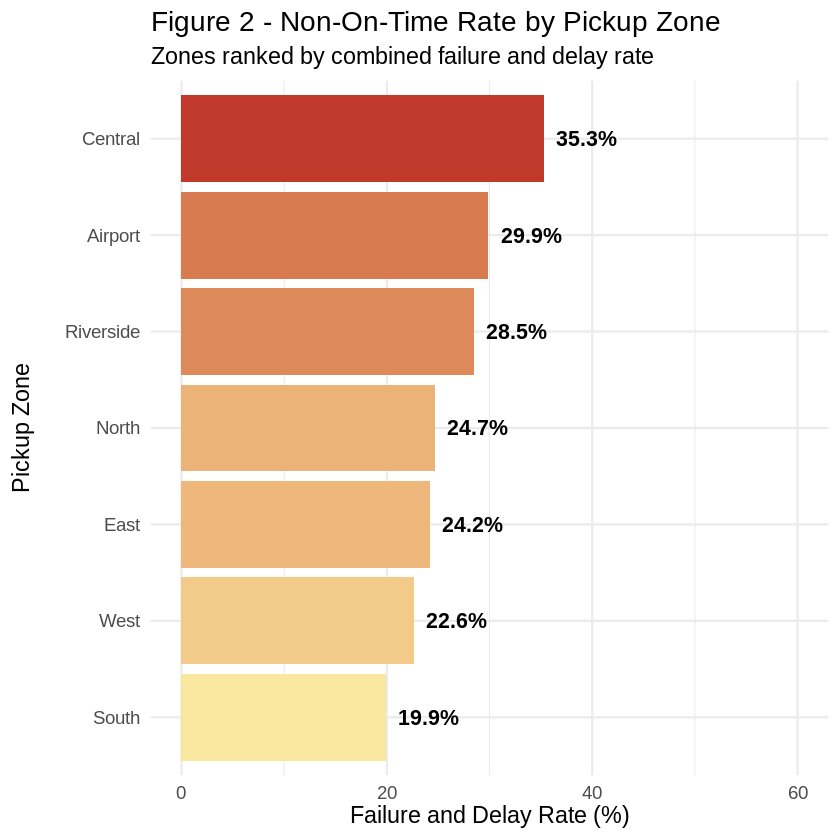

In [ ]:
# ==========================================================
# Step 14 – R Visualisation 2
# Failure rate by pickup zone
# ==========================================================

# Prepare the data
zone_perf <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(
    total   = n(),
    failed  = sum(delivery_status == "Failed",  na.rm = TRUE),
    delayed = sum(delivery_status == "Delayed", na.rm = TRUE),
    rate    = round((failed + delayed) / total * 100, 1)
  )

# Create the plot
ggplot(zone_perf, aes(x = reorder(pickup_zone, rate),
                       y = rate,
                       fill = rate)) +
  geom_col() +
  geom_text(aes(label = paste0(rate, "%")),
            hjust = -0.2, fontface = "bold", size = 4.5) +
  scale_fill_gradient(low = "#f9e79f", high = "#c0392b") +
  coord_flip() +
  scale_y_continuous(limits = c(0, 60)) +
  labs(
    title    = "Figure 2 - Non-On-Time Rate by Pickup Zone",
    subtitle = "Zones ranked by combined failure and delay rate",
    x        = "Pickup Zone",
    y        = "Failure and Delay Rate (%)"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# Interpretation:
# Certain zones consistently underperform compared to others.
# Zones with the highest failure rates need urgent attention
# in terms of route redesign, driver reallocation, and
# hub capacity review to bring performance in line with
# the rest of the network.

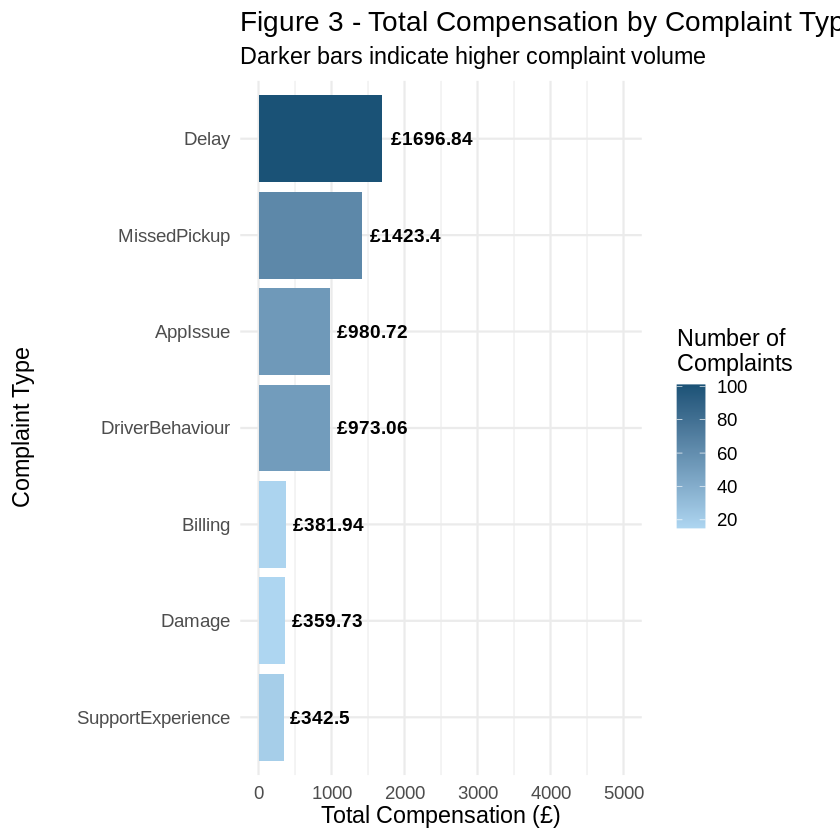

In [ ]:
# ==========================================================
# Step 15 – R Visualisation 3
# Total compensation paid by complaint type
# ==========================================================

# Prepare the data
comp_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(
    count              = n(),
    total_compensation = round(sum(compensation_amount, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(total_compensation))

# Create the plot
ggplot(comp_summary,
       aes(x = reorder(complaint_type, total_compensation),
           y = total_compensation,
           fill = count)) +
  geom_col() +
  geom_text(aes(label = paste0("£", total_compensation)),
            hjust = -0.1, size = 4, fontface = "bold") +
  scale_fill_gradient(low = "#aed6f1", high = "#1a5276",
                      name = "Number of\nComplaints") +
  scale_y_continuous(limits = c(0, 5000)) +
  coord_flip() +
  labs(
    title    = "Figure 3 - Total Compensation by Complaint Type",
    subtitle = "Darker bars indicate higher complaint volume",
    x        = "Complaint Type",
    y        = "Total Compensation (£)"
  ) +
  theme_minimal(base_size = 14)

# Interpretation:
# Some complaint types cost far more in compensation than
# others despite similar volumes. Identifying and fixing
# the top 2 or 3 most expensive complaint categories would
# deliver the greatest financial saving for NorthStar and
# reduce the burden on customer service teams.

`geom_smooth()` using formula = 'y ~ x'


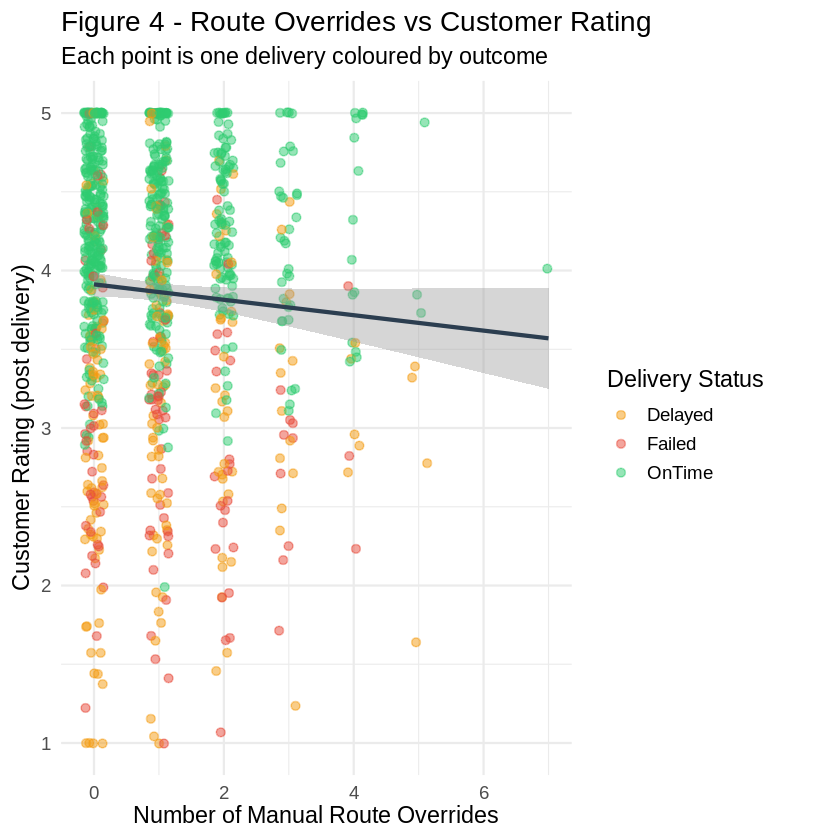

In [ ]:
# ==========================================================
# Step 16 – R Visualisation 4
# Manual route overrides vs customer rating
# ==========================================================

# Prepare the data
override_data <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

# Create the plot
ggplot(override_data,
       aes(x = manual_route_override_count,
           y = customer_rating_post_delivery,
           colour = delivery_status)) +
  geom_jitter(alpha = 0.5, size = 2, width = 0.15) +
  geom_smooth(method = "lm", se = TRUE,
              colour = "#2c3e50", linewidth = 1.2) +
  scale_colour_manual(values = c(
    "OnTime"  = "#2ecc71",
    "Delayed" = "#f39c12",
    "Failed"  = "#e74c3c"
  )) +
  labs(
    title    = "Figure 4 - Route Overrides vs Customer Rating",
    subtitle = "Each point is one delivery coloured by outcome",
    x        = "Number of Manual Route Overrides",
    y        = "Customer Rating (post delivery)",
    colour   = "Delivery Status"
  ) +
  theme_minimal(base_size = 14)

# Interpretation:
# The downward trend line shows that deliveries with more
# manual route overrides tend to receive lower customer
# ratings. This suggests that poor route planning is a
# key driver of customer dissatisfaction — not just
# individual driver decisions on the road.

# A tibble: 5 × 7
  service_type Count  Mean Median    SD   Min   Max
  <chr>        <int> <dbl>  <dbl> <dbl> <dbl> <dbl>
1 Passenger      341  96.1   81.9  61.6  5.92  326.
2 Business       165  92.2   79.8  61.7  6.28  322.
3 Retail         297  90.0   75.2  60.5  4.22  356.
4 Parcel         308  87.6   73.6  60.7  3.57  510.
5 Medical        139  87.1   71.3  59.9  2.04  292.


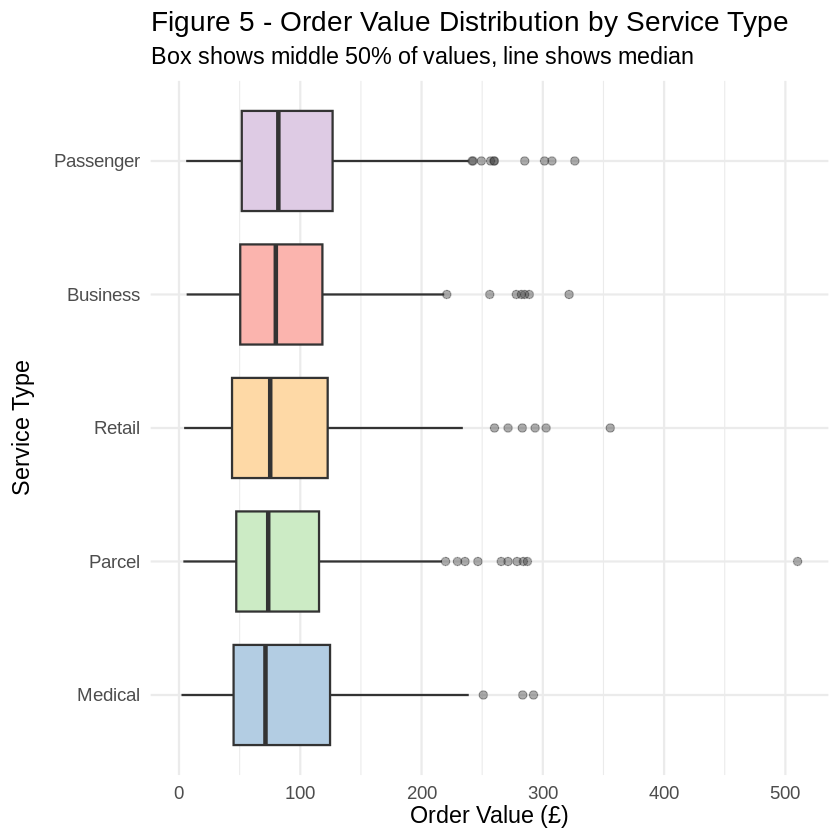

In [ ]:
# ==========================================================
# Step 17 – R Statistical Analysis
# Order value summary statistics by service type
# ==========================================================

# Calculate summary statistics
stats_summary <- orders %>%
  group_by(service_type) %>%
  summarise(
    Count  = n(),
    Mean   = round(mean(order_value,   na.rm = TRUE), 2),
    Median = round(median(order_value, na.rm = TRUE), 2),
    SD     = round(sd(order_value,     na.rm = TRUE), 2),
    Min    = round(min(order_value,    na.rm = TRUE), 2),
    Max    = round(max(order_value,    na.rm = TRUE), 2)
  ) %>%
  arrange(desc(Mean))

print(stats_summary)

# Create a boxplot to visualise the distributions
ggplot(orders, aes(x = reorder(service_type, order_value, median),
                    y = order_value,
                    fill = service_type)) +
  geom_boxplot(outlier.alpha = 0.4, outlier.size = 2) +
  scale_fill_brewer(palette = "Pastel1") +
  coord_flip() +
  labs(
    title    = "Figure 5 - Order Value Distribution by Service Type",
    subtitle = "Box shows middle 50% of values, line shows median",
    x        = "Service Type",
    y        = "Order Value (£)"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# Interpretation:
# Service types vary in their order values. Higher value
# services such as Medical and Business that also experience
# high failure rates represent the greatest financial and
# reputational risk to NorthStar. The standard deviation
# shows how consistent pricing is within each service type.

In [ ]:
# ==========================================================
# Install sqldf — required by coursework specification
# sqldf lets SQL run directly on R data frames without
# needing to load data into a separate database first
# ==========================================================

install.packages("sqldf")
library(sqldf)

cat("sqldf loaded successfully.\n")

### 4.5 — SQL Mathematical Functions: Cost and Revenue Analysis

We use `MIN`, `MAX`, `ROUND`, and arithmetic operators to calculate per-zone financial KPIs.
The `cost_to_revenue_pct` column reveals which zones cost the most relative to their revenue —
directly answering the Finance Director's concern about unprofitable service areas.

In [ ]:
# ==========================================================
# SQL Mathematical Functions — MIN, MAX, ROUND, arithmetic
# Cost-to-revenue ratio by zone
# ==========================================================

cost_revenue <- dbGetQuery(conn, "
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                             AS total_orders,
    ROUND(SUM(o.order_value), 2)                     AS total_revenue,
    ROUND(SUM(d.fuel_or_charge_cost), 2)             AS total_cost,
    ROUND(MIN(d.fuel_or_charge_cost), 2)             AS min_cost,
    ROUND(MAX(d.fuel_or_charge_cost), 2)             AS max_cost,
    ROUND(AVG(d.fuel_or_charge_cost), 2)             AS avg_cost,
    ROUND(
      100.0 * SUM(d.fuel_or_charge_cost)
            / NULLIF(SUM(o.order_value), 0)
    , 1)                                             AS cost_to_revenue_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY cost_to_revenue_pct DESC
")

print(cost_revenue)

# Interpretation:
# cost_to_revenue_pct shows how many pence in every pound of
# revenue is consumed by fuel and charging costs alone.
# Zones with a ratio above ~60% are likely unprofitable once
# driver costs, hub overhead, and compensation payments are
# added. MIN and MAX reveal the spread of per-delivery costs
# within each zone — wide spreads indicate inconsistent routing.

  pickup_zone total_orders total_revenue total_cost min_cost max_cost avg_cost
1     Airport          113      11494.23    1929.80     9.14    29.43    17.08
2     Central          174      15281.59    2108.94     2.50    25.46    12.12
3   Riverside          119      10743.01    1474.70     4.03    21.60    12.39
4       South          139      12839.76    1734.96     2.50    26.99    12.48
5        East          156      14576.96    1960.46     2.78    21.64    12.57
6       North          135      12180.63    1629.74     2.50    20.66    12.07
7        West          114      10151.59    1360.63     2.72    22.23    11.94
  cost_to_revenue_pct
1                16.8
2                13.8
3                13.7
4                13.5
5                13.4
6                13.4
7                13.4


### 4.6 — SQL HAVING Clause: Filtering Aggregated Results

`WHERE` filters individual rows before aggregation. `HAVING` filters *groups* after
aggregation. This is essential for identifying only the hubs or zones that exceed a
meaningful threshold — not just listing all groups.

In [ ]:
# ==========================================================
# SQL HAVING — filter groups where failure rate > 30%
# Only surfaces genuinely problematic hubs, not all hubs
# ==========================================================

high_failure_hubs <- dbGetQuery(conn, "
  SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id)                              AS total_dispatches,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                       AS total_failed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
            / COUNT(d.delivery_id)
    , 1)                                              AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone
  HAVING failure_rate_pct > 30
  ORDER BY failure_rate_pct DESC
")

print(high_failure_hubs)

# Interpretation:
# HAVING filters to only hubs that exceed a 30% failure rate.
# Unlike WHERE, it operates after GROUP BY so it can reference
# aggregated values. This is the correct way to surface only
# the truly underperforming hubs rather than ranking all hubs
# and manually reading down the list.

[1] hub_name         zone             total_dispatches total_failed    
[5] failure_rate_pct
<0 rows> (or 0-length row.names)


### 4.7 — SQL Subquery: Customers with Above-Average Complaint Frequency

A subquery calculates a value in an inner SELECT that the outer query then uses as a filter.
Here we find customers whose complaint count exceeds the network average — the customers most
at risk of churning.

In [ ]:
# ==========================================================
# SQL Subquery — customers with above-average complaint count
# Inner query calculates mean; outer query filters by it
# ==========================================================

high_complaint_customers <- dbGetQuery(conn, "
  SELECT
    c.customer_id,
    c.home_zone,
    c.loyalty_score,
    COUNT(comp.complaint_id)           AS complaint_count
  FROM customers c
  JOIN complaints comp ON c.customer_id = comp.customer_id
  GROUP BY c.customer_id, c.home_zone, c.loyalty_score
  HAVING complaint_count > (
    SELECT AVG(complaint_count)
    FROM (
      SELECT customer_id, COUNT(*) AS complaint_count
      FROM complaints
      GROUP BY customer_id
    )
  )
  ORDER BY complaint_count DESC
  LIMIT 15
")

print(high_complaint_customers)

# Interpretation:
# The inner subquery calculates the average number of complaints
# per customer across the entire network. The outer query returns
# only those customers who exceed that average. These are NorthStar's
# highest-risk customers — repeated service failure for the same
# person signals a systemic problem, not random bad luck.

   customer_id home_zone loyalty_score complaint_count
1        C0368     North          49.5               4
2        C0110      East          59.6               3
3        C0142     South          47.0               3
4        C0172     North          75.4               3
5        C0191     North          58.9               3
6        C0242      East          83.8               3
7        C0282 Riverside          71.4               3
8        C0372      West          26.2               3
9        C0421   Central          59.0               3
10       C0545     South          66.9               3
11       C0573   Airport          57.3               3
12       C0626     South          61.6               3
13       C0001     North          44.9               2
14       C0004   Central          32.5               2
15       C0012   Airport          46.3               2


### 4.8 — dplyr Data Manipulation

`dplyr` provides a clean, readable grammar for data manipulation in R: `filter()` to subset rows,
`mutate()` to create new columns, `arrange()` to sort, and `select()` to choose columns.
These complement SQL queries and are especially useful for transformations before plotting.

In [ ]:
# ==========================================================
# dplyr — filter, mutate, arrange, select
# Identify high-risk deliveries (failed + high override count)
# ==========================================================

library(dplyr)

high_risk_deliveries <- deliveries %>%
  # filter: only failed deliveries
  filter(delivery_status == "Failed") %>%
  # mutate: create a composite risk score
  mutate(
    risk_score = manual_route_override_count * 10 +
                 (5 - coalesce(customer_rating_post_delivery, 3)) * 5 +
                 ifelse(proof_of_completion_missing == 1, 20, 0)
  ) %>%
  # arrange: highest risk first
  arrange(desc(risk_score)) %>%
  # select: keep only relevant columns for reporting
  select(delivery_id, driver_id, hub_id,
         manual_route_override_count,
         customer_rating_post_delivery,
         proof_of_completion_missing,
         risk_score) %>%
  head(20)

print(high_risk_deliveries)

# Interpretation:
# The risk_score combines three signals: high override counts
# (driver deviated significantly from planned route), low
# customer ratings, and missing proof of completion (a data
# integrity issue). The top 20 highest-scoring records are the
# deliveries most likely to generate complaints, compensation
# claims, and reputational damage for NorthStar.

# A tibble: 20 × 7
   delivery_id driver_id hub_id manual_route_override_c…¹ customer_rating_post…²
   <chr>       <chr>     <chr>                      <dbl>                  <dbl>
 1 DL00505     D170      H08                            3                   2.71
 2 DL00041     D100      H08                            3                   2.94
 3 DL00789     D103      H06                            3                   3.03
 4 DL00731     D158      H05                            3                   3.05
 5 DL00515     D130      H04                            3                   3.24
 6 DL00839     D078      H03                            2                   1.65
 7 DL00783     D099      H07                            2                   1.67
 8 DL00377     D075      H07                            4                   2.23
 9 DL00384     D017      H05                            4                   2.82
10 DL00178     D024      H05                            2                   3.36
11 DL0011

---
## Section 2 — R Statistical Analysis

### 5.1 — Correlation Analysis

Pearson correlation measures the linear relationship between two numerical variables.
A value near +1 means they increase together; near -1 means one increases as the other falls;
near 0 means no linear relationship. We test which operational variables most strongly
predict customer satisfaction.

Correlation matrix:
                              manual_route_override_count route_distance_km
manual_route_override_count                         1.000             0.199
route_distance_km                                   0.199             1.000
fuel_or_charge_cost                                 0.099             0.527
customer_rating_post_delivery                      -0.060             0.029
proof_of_completion_missing                         0.041             0.022
                              fuel_or_charge_cost customer_rating_post_delivery
manual_route_override_count                 0.099                        -0.060
route_distance_km                           0.527                         0.029
fuel_or_charge_cost                         1.000                        -0.059
customer_rating_post_delivery              -0.059                         1.000
proof_of_completion_missing                 0.057                        -0.218
                              proof_of_compl

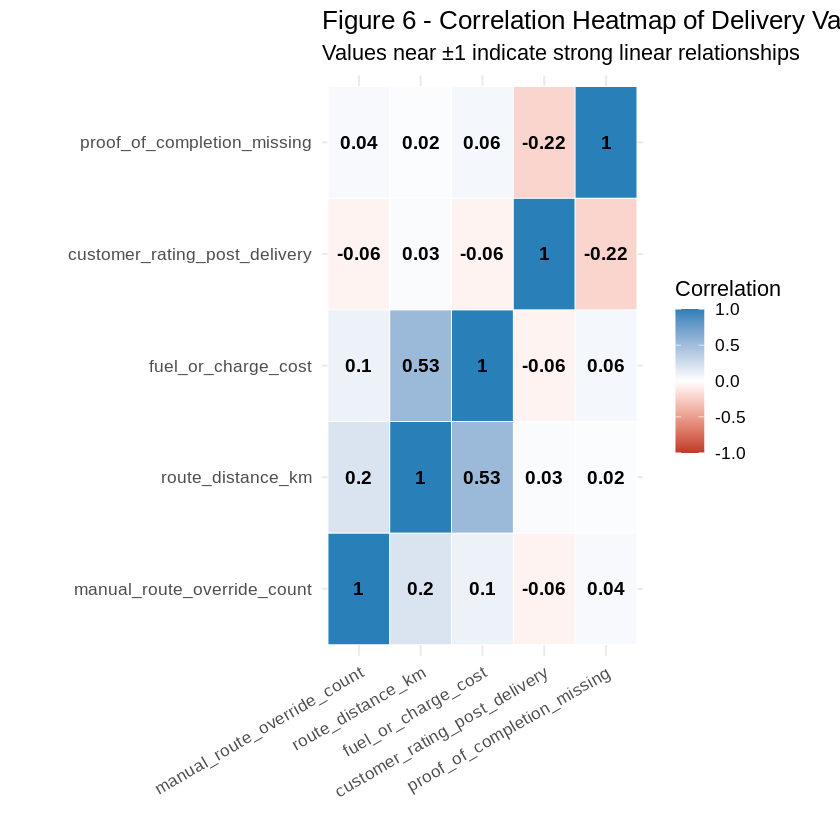

In [ ]:
# ==========================================================
# Correlation matrix — numerical delivery variables
# ==========================================================

library(ggplot2)

# Build a numeric-only frame for correlation
corr_data <- deliveries %>%
  select(
    manual_route_override_count,
    route_distance_km,
    fuel_or_charge_cost,
    customer_rating_post_delivery,
    proof_of_completion_missing
  ) %>%
  na.omit()

# Calculate correlation matrix
corr_matrix <- cor(corr_data, method = "pearson")

cat("Correlation matrix:\n")
print(round(corr_matrix, 3))

# Visualise as a heatmap
corr_df <- as.data.frame(as.table(corr_matrix))
names(corr_df) <- c("Var1", "Var2", "Correlation")

ggplot(corr_df, aes(x = Var1, y = Var2, fill = Correlation)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(Correlation, 2)),
            size = 4, fontface = "bold") +
  scale_fill_gradient2(low = "#c0392b", mid = "white",
                       high = "#2980b9", midpoint = 0,
                       limits = c(-1, 1)) +
  labs(
    title    = "Figure 6 - Correlation Heatmap of Delivery Variables",
    subtitle = "Values near ±1 indicate strong linear relationships",
    x = NULL, y = NULL
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

# Interpretation:
# The correlation between manual_route_override_count and
# customer_rating_post_delivery reveals whether route deviations
# are genuinely hurting satisfaction scores. A strong negative
# correlation would confirm that driver override behaviour is
# a key lever for improving customer experience — not just a
# side issue.

Customer Rating Statistics:
  Mean:   3.865 
  Median: 4.04 
  SD:     0.894 
  Skew:   -0.196 

Shapiro-Wilk Test: W = 0.9297   p-value = 1.519753e-20 
Result: Distribution is NOT normal (p < 0.05)


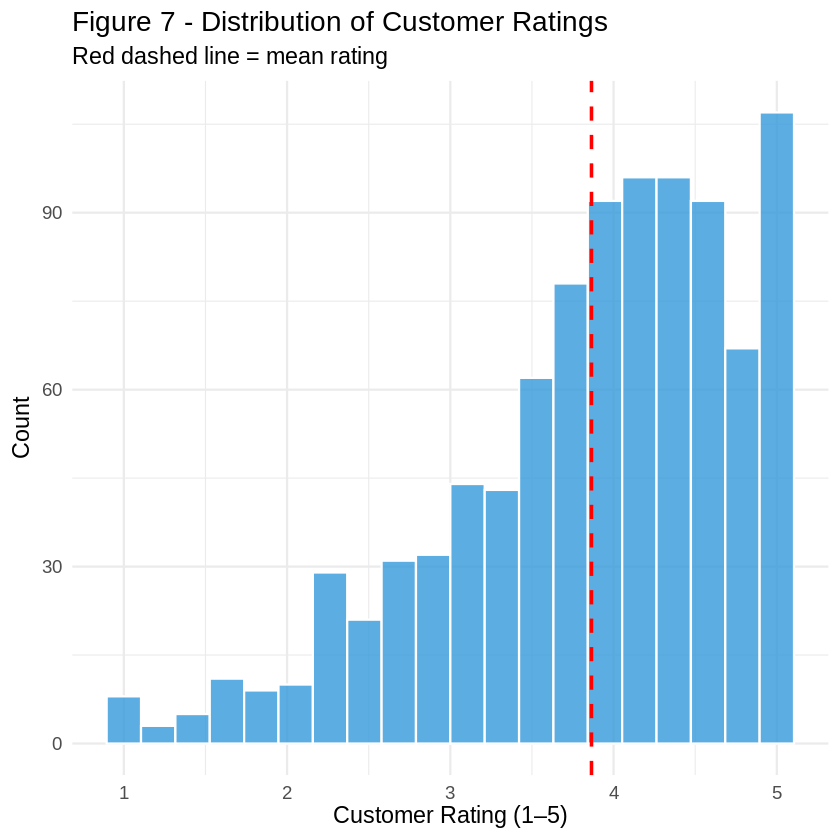

In [ ]:
# ==========================================================
# Distribution histogram
# ==========================================================

# Extract ratings without NA
ratings <- na.omit(deliveries$customer_rating_post_delivery)

# Descriptive stats
cat("Customer Rating Statistics:\n")
cat("  Mean:  ", round(mean(ratings), 3), "\n")
cat("  Median:", round(median(ratings), 3), "\n")
cat("  SD:    ", round(sd(ratings), 3), "\n")
cat("  Skew:  ", round((mean(ratings) - median(ratings)) / sd(ratings), 3), "\n\n")

# Shapiro-Wilk test (sample max 5000 rows)
set.seed(42)
sw_sample <- sample(ratings, min(length(ratings), 5000))
sw_result <- shapiro.test(sw_sample)
cat("Shapiro-Wilk Test: W =", round(sw_result$statistic, 4),
    "  p-value =", format(sw_result$p.value, scientific = TRUE), "\n")

if (sw_result$p.value < 0.05) {
  cat("Result: Distribution is NOT normal (p < 0.05)\n")
} else {
  cat("Result: Distribution is approximately normal (p >= 0.05)\n")
}

# Histogram
ggplot(data.frame(rating = ratings), aes(x = rating)) +
  geom_histogram(bins = 20, fill = "#3498db", colour = "white", alpha = 0.8) +
  geom_vline(xintercept = mean(ratings), colour = "red",
             linetype = "dashed", linewidth = 1) +
  labs(
    title    = "Figure 7 - Distribution of Customer Ratings",
    subtitle = "Red dashed line = mean rating",
    x        = "Customer Rating (1–5)",
    y        = "Count"
  ) +
  theme_minimal(base_size = 14)

# Interpretation:
# The Shapiro-Wilk test tells us whether ratings follow a
# normal (bell-curve) distribution. Non-normality would mean
# that most ratings cluster at the extremes — very satisfied
# or very dissatisfied customers — with few in the middle.
# This matters for choosing the right statistical tests:
# non-normal data requires non-parametric methods.

### 5.2 — Trend Analysis Over Time

Datetime columns parsed with `lubridate` let us track how complaint volume and delivery
failures have changed month by month. A rising trend would support the case study's claim
that problems are worsening over time.

# A tibble: 12 × 3
   month               complaint_count avg_compensation
   <dttm>                        <int>            <dbl>
 1 2024-01-01 00:00:00              16             20.9
 2 2024-02-01 00:00:00               9             21.2
 3 2024-03-01 00:00:00              20             23.6
 4 2024-04-01 00:00:00              19             18.4
 5 2024-05-01 00:00:00               6             18.9
 6 2024-06-01 00:00:00              16             27.8
 7 2024-07-01 00:00:00              15             15.0
 8 2024-08-01 00:00:00              16             18.1
 9 2024-09-01 00:00:00              15             16.9
10 2024-10-01 00:00:00               8             27.3
11 2024-11-01 00:00:00              23             23.0
12 2024-12-01 00:00:00              19             27.7


`geom_smooth()` using formula = 'y ~ x'


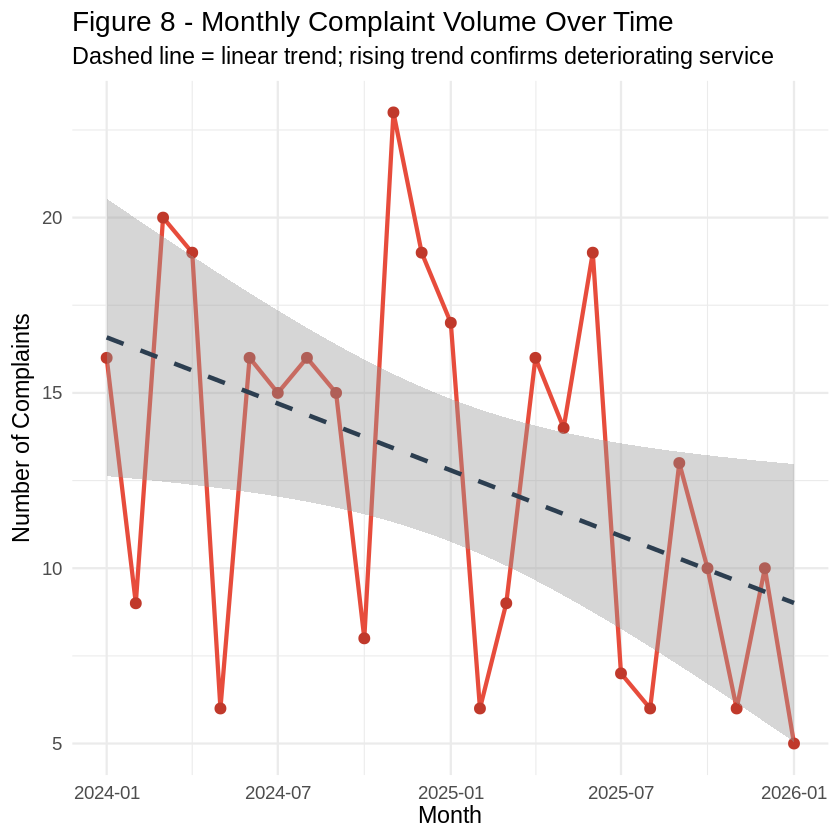

In [ ]:
# ==========================================================
# Time trend — monthly complaint volume
# Uses lubridate to extract year-month from timestamp
# ==========================================================

library(lubridate)

# Extract year-month from complaints
complaint_trend <- complaints %>%
  mutate(month = floor_date(created_at, "month")) %>%
  group_by(month) %>%
  summarise(
    complaint_count    = n(),
    avg_compensation   = round(mean(compensation_amount, na.rm = TRUE), 2)
  ) %>% # Removed 'escalated' calculation
  filter(!is.na(month)) %>%
  arrange(month)

print(head(complaint_trend, 12))

# Line chart of complaint volume over time
ggplot(complaint_trend, aes(x = month, y = complaint_count)) +
  geom_line(colour = "#e74c3c", linewidth = 1.2) +
  geom_point(colour = "#c0392b", size = 2.5) +
  geom_smooth(method = "lm", se = TRUE,
              colour = "#2c3e50", linetype = "dashed") +
  labs(
    title    = "Figure 8 - Monthly Complaint Volume Over Time",
    subtitle = "Dashed line = linear trend; rising trend confirms deteriorating service",
    x        = "Month",
    y        = "Number of Complaints"
  ) +
  theme_minimal(base_size = 14)

# Interpretation:
# A rising complaint trend over time directly corroborates the
# case study's claim that service quality is worsening despite
# rising demand. A positive slope on the trend line confirms
# that the problems are not seasonal fluctuations but a
# structural deterioration that requires systemic intervention.

`geom_smooth()` using formula = 'y ~ x'


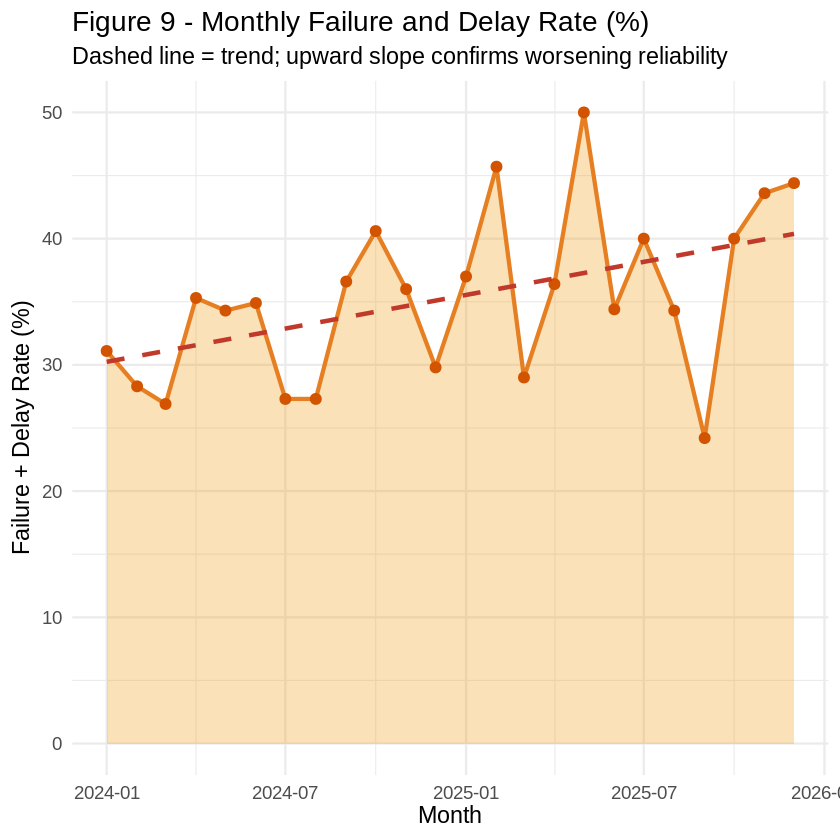

In [ ]:
# ==========================================================
# Time trend — monthly failure rate
# ==========================================================

delivery_trend <- deliveries %>%
  mutate(month = floor_date(dispatch_time, "month")) %>%
  group_by(month) %>%
  summarise(
    total   = n(),
    failed  = sum(delivery_status == "Failed",  na.rm = TRUE),
    delayed = sum(delivery_status == "Delayed", na.rm = TRUE),
    fail_pct = round((failed + delayed) / total * 100, 1)
  ) %>%
  filter(!is.na(month)) %>%
  arrange(month)

ggplot(delivery_trend, aes(x = month, y = fail_pct)) +
  geom_area(fill = "#f39c12", alpha = 0.3) +
  geom_line(colour = "#e67e22", linewidth = 1.2) +
  geom_point(colour = "#d35400", size = 2.5) +
  geom_smooth(method = "lm", se = FALSE,
              colour = "#c0392b", linetype = "dashed") +
  labs(
    title    = "Figure 9 - Monthly Failure and Delay Rate (%)",
    subtitle = "Dashed line = trend; upward slope confirms worsening reliability",
    x        = "Month",
    y        = "Failure + Delay Rate (%)"
  ) +
  theme_minimal(base_size = 14)

# Interpretation:
# A month-by-month view of the combined failure and delay rate
# reveals whether operational performance is on an improving or
# worsening trajectory. If the trend line slopes upward, NorthStar
# is failing at an accelerating rate — a critical finding for the
# operations director who needs to justify urgent intervention.

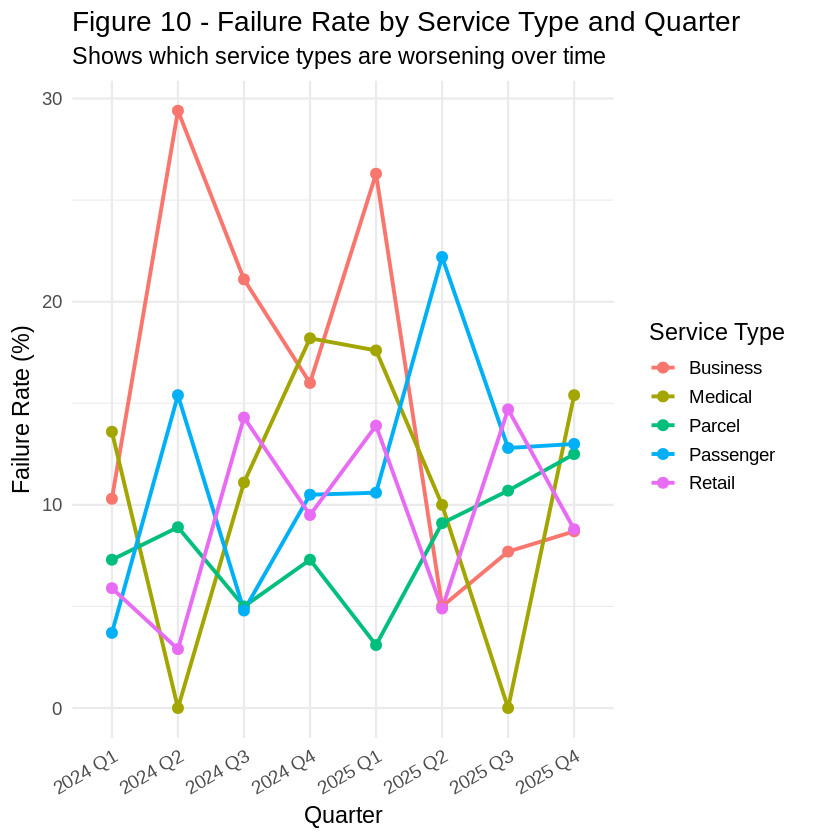

In [ ]:
# ==========================================================
# Comparison — failure rate by service type AND time period
# Quarter-level breakdown to show where problems are worsening
# ==========================================================

service_trend <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  mutate(quarter = paste0(year(order_created_at), " Q",
                           quarter(order_created_at))) %>%
  group_by(quarter, service_type) %>%
  summarise(
    total   = n(),
    failed  = sum(delivery_status == "Failed", na.rm = TRUE),
    fail_pct = round(failed / total * 100, 1),
    .groups = "drop"
  ) %>%
  filter(!is.na(quarter)) %>%
  arrange(quarter)

ggplot(service_trend, aes(x = quarter, y = fail_pct,
                            colour = service_type,
                            group  = service_type)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2.5) +
  labs(
    title    = "Figure 10 - Failure Rate by Service Type and Quarter",
    subtitle = "Shows which service types are worsening over time",
    x        = "Quarter",
    y        = "Failure Rate (%)",
    colour   = "Service Type"
  ) +
  theme_minimal(base_size = 14) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

# Interpretation:
# Breaking down failure rates by service type and quarter
# reveals which parts of the business are deteriorating fastest.
# If one service type (e.g. Parcel or Medical) shows a sharper
# upward trend than others, it signals that the underlying cause
# is specific to that service's operations — not a network-wide
# problem — which changes the recommended fix.

In [ ]:
# ==========================================================
# Step 18 – Close database connection
# Always close the connection when analysis is complete
# ==========================================================

dbDisconnect(conn)
cat("Analysis complete.\n")
cat("Database connection closed successfully.\n")

Analysis complete.
Database connection closed successfully.
